This notebook trains two models: one for cost prediction and another for conversion prediction. The cost prediction model predicts the cost of a rider, while the conversion prediction model predicts whether a rider will convert to a ride or not. The two models are used as key components in Thea's policy. 

In [1]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
from sklearn.metrics import roc_auc_score, log_loss, roc_curve
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import random

import joblib

import os
import sys
# Add the parent directory to Python path
parent_dir = os.path.dirname(os.getcwd())
sys.path.append(parent_dir)
from utils import populate_shared_ride_lengths # Will be very useful!

# Load the data

In [2]:
# Load in updated training dataset
riders_df = pd.read_csv('../data/training_data.csv')

# Preprocessing: Add per-rider cost

In [3]:
# calculate the cost allocated to each rider
def cost(row, rider_lookup):
    if pd.isna(row['matching_outcome']):
        return row['solo_length']
    else:
        matched_rider = row['matching_outcome']
        
        # Check if matched rider exists in lookup
        if matched_rider not in rider_lookup:
            return row['solo_length']  # Fallback
            
        matched_data = rider_lookup[matched_rider]
        
        origin_i = (row['pickup_lat'], row['pickup_lon'])
        destination_i = (row['dropoff_lat'], row['dropoff_lon'])
        origin_j = (matched_data['pickup_lat'], matched_data['pickup_lon'])
        destination_j = (matched_data['dropoff_lat'], matched_data['dropoff_lon'])
        
        trip_length, shared_length, i_solo_length, j_solo_length, trip_order = populate_shared_ride_lengths(
            origin_i, destination_i, origin_j, destination_j
        )
        
        return (i_solo_length + shared_length/2)

# Create lookup dictionary once
# set a two-level index on rider_id and seed
rider_lookup = riders_df.set_index(['rider_id'])[["pickup_lat", "pickup_lon", "dropoff_lat", "dropoff_lon"]].to_dict('index')

# Apply with lookup
riders_df['cost_length'] = riders_df.apply(lambda row: cost(row, rider_lookup), axis=1)
c = 0.7
riders_df['cost'] = riders_df['cost_length'] * c / riders_df['solo_length']

# Model training 

## Model 1: Cost prediction model
- Features: solo_length, pickup_area, dropoff_area (one-hot encoded)
- Target: cost (\$ per mile)

In [ ]:
# Prepare features and target
X_cost = pd.get_dummies(riders_df[['solo_length', 'pickup_area', 'dropoff_area']],
                       columns=['pickup_area', 'dropoff_area'],
                       dtype=int)
y_cost = riders_df['cost']

# Split data: the models are trained using 80% of the data, and the remaining 20% is used for testing.
X_cost_train, X_cost_test, y_cost_train, y_cost_test = train_test_split(
    X_cost, y_cost, test_size=0.2, random_state=42
)

# Train model
cost_model = LinearRegression()
cost_model.fit(X_cost_train, y_cost_train)

# Store feature names for consistency
encoded_feats = X_cost_train.columns.tolist()

## Model 2: Conversion prediction model
- Features: quoted_price, pickup_area, dropoff_area (one-hot encoded)
- Target: conversion probability (in [0, 1])

In [5]:
# Prepare features (reuse encoding structure but exclude solo_length, add quoted_price)
X_conversion = pd.get_dummies(riders_df[['pickup_area', 'dropoff_area']], 
                             columns=['pickup_area', 'dropoff_area'], 
                             dtype=int)
X_conversion['quoted_price'] = riders_df['quoted_price']

# Ensure consistent column ordering with cost model (minus solo_length)
conversion_feature_names = [col for col in encoded_feats if col != 'solo_length']
conversion_feature_names.append('quoted_price')
X_conversion = X_conversion.reindex(columns=conversion_feature_names, fill_value=0)

y_conversion = riders_df['convert_or_not']

# Split data
X_conversion_train, X_conversion_test, y_conversion_train, y_conversion_test = train_test_split(
    X_conversion, y_conversion, test_size=0.2, random_state=42
)

# Train model
conversion_model = LogisticRegression()
conversion_model.fit(X_conversion_train, y_conversion_train)

LogisticRegression()

## Save the trained models and features

In [11]:
# Save the models
joblib.dump(cost_model, 'models/cost_model.joblib')
joblib.dump(conversion_model, 'models/conversion_model.joblib')
joblib.dump(encoded_feats, 'models/encoded_features.joblib')

['models/encoded_features.joblib']

# Test set evaluation

We can evaluate the two models on the test set to see how well they perform.

## 1. Evaluating the cost prediction model

In [6]:
# Make predictions on test set
y_pred_cost = cost_model.predict(X_cost_test)

# Calculate metrics
mse_cost = mean_squared_error(y_cost_test, y_pred_cost)
mae_cost = mean_absolute_error(y_cost_test, y_pred_cost)
r2_cost = r2_score(y_cost_test, y_pred_cost)
rmse_cost = np.sqrt(mse_cost)

print("=== COST MODEL PERFORMANCE ===")
print(f"Test MSE: {mse_cost:.4f}")
print(f"Test MAE: {mae_cost:.4f}")
print(f"Test R squared: {r2_cost:.4f}")
print(f"Test RMSE: {rmse_cost:.4f}")
print()

=== COST MODEL PERFORMANCE ===
Test MSE: 0.0159
Test MAE: 0.0948
Test R squared: 0.0633
Test RMSE: 0.1262



## 2. Evaluating the conversion prediction model

=== CONVERSION MODEL PERFORMANCE ===
Test Accuracy: 0.6412
AUC-ROC: 0.679
Log Loss: 0.634
Baseline Log Loss: 0.682


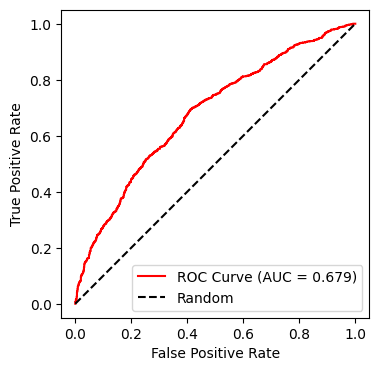

In [7]:
# Make predictions on test set
y_pred_conversion = conversion_model.predict(X_conversion_test)
y_pred_proba_conversion = conversion_model.predict_proba(X_conversion_test)[:, 1]

# Calculate metrics
accuracy_conversion = accuracy_score(y_conversion_test, y_pred_conversion)
auc_score = roc_auc_score(y_conversion_test, y_pred_proba_conversion)
logloss = log_loss(y_conversion_test, y_pred_proba_conversion)

print("=== CONVERSION MODEL PERFORMANCE ===")
print(f"Test Accuracy: {accuracy_conversion:.4f}")
print(f"AUC-ROC: {auc_score:.3f}")
print(f"Log Loss: {logloss:.3f}")

# Compare with a baseline model that predicts the mean conversion rate.
empirical_p = y_conversion_train.mean()
baseline_logloss = log_loss(y_conversion_test, np.full_like(y_conversion_test, empirical_p, dtype=float))
# print(f"Empirical Probability of Conversion: {empirical_p:.3f}")
print(f"Baseline Log Loss: {baseline_logloss:.3f}")

# ROC Curve
fpr, tpr, _ = roc_curve(y_conversion_test, y_pred_proba_conversion)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
# plt.savefig('roc_curve.pdf', bbox_inches='tight')
plt.show()

